# Аналіз та візуалізація мережевих даних

## Завдання
Використовуючи бібліотеку `networkx`, побудувати граф для аналізу взаємозв'язків між об'єктами у мережі. Дослідити ключові вузли (хаби) та візуалізувати їх.

## Суть завдання
Мета цієї роботи — змоделювати мережу (наприклад, телекомунікаційну, соціальну чи логістичну) та застосувати алгоритми графового аналізу для її вивчення. 
Ми використовуємо метрики **центральності (Centrality)**, щоб знайти найважливіші вузли:
- **Degree Centrality** (Центральність за ступенем): кількість зв'язків у вузла. Показує найвпливовіших "сусідів".
- **Betweenness Centrality** (Центральність за посередництвом): як часто вузол лежить на найкоротших шляхах між іншими вузлами. Показує ключові "мости", вимкнення яких розірве зв'язок між частинами мережі.

Код автоматично генерує топологію мережі, знаходить ці ключові вузли та підсвічує їх на графіку.

## Опис результатів
1. **Графік**: Мережа, де великими кольоровими кругами виділені **хаби** (вузли з найбільшим значенням посередництва). Інші вузли зображені меншими. 
2. **Аналітика в консолі**: Виведення топ-3 найважливіших вузлів (як за кількістю зв'язків, так і за їхньою "пропускною" здатністю). Розрахунок найкоротшого шляху для передачі даних між двома віддаленими точками.

## Приклади реального використання
1. **IT та телекомунікації**: Пошук "вузьких місць" (bottlenecks) в інфраструктурі провайдера. Якщо маршрутизатор має високу *Betweenness Centrality*, весь трафік йде через нього. Інженери дублюють канали зв'язку в обхід цього хаба, щоб уникнути перевантажень.
2. **Соціальні мережі та маркетинг**: Пошук лідерів думок в Instagram чи Twitter. Користувачі з високою *Degree Centrality* мають найбільше підписників і з найвищою ймовірністю забезпечать швидке розповсюдження інформації у своєму середовищі.


--- Аналіз взаємозв'язків у мережі об'єктів ---

Топ-3 вузли за кількістю зв'язків (Degree Centrality):
 - Вузол 0: 0.586
 - Вузол 2: 0.517
 - Вузол 3: 0.276

Топ-3 'мости' мережі, через які проходить найбільше трафіку (Betweenness Centrality):
 - Вузол 0: 0.478
 - Вузол 2: 0.344
 - Вузол 3: 0.128

Оптимальний маршрут обміну даними між Вузлом 0 та Вузлом 29:
0 -> 29

Висновок: Великі червоні вузли на графіку — це критична інфраструктура системи.


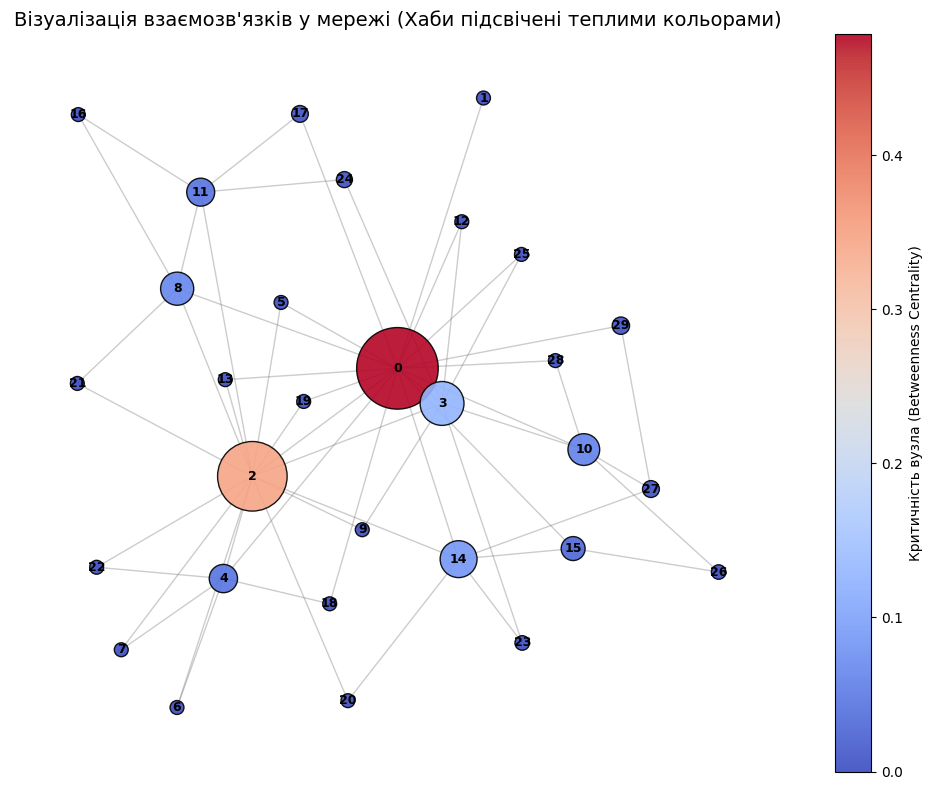

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

class NetworkDataAnalyzer:
    def __init__(self, num_nodes, edges_per_node):
        # Scale-free network (Barabasi-Albert model) - widely used for real-world networks
        self.graph = nx.barabasi_albert_graph(n=num_nodes, m=edges_per_node, seed=120)
        self.degree_centrality = {}
        self.betweenness_centrality = {}

    def analyze_relationships(self):
        # Compute centrality metrics
        self.degree_centrality = nx.degree_centrality(self.graph)
        self.betweenness_centrality = nx.betweenness_centrality(self.graph)
        
    def get_top_nodes(self, centrality_dict, top_n=3):
        return sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)[:top_n]

    def visualize_network(self):
        plt.figure(figsize=(10, 8))
        
        # Spring layout frames clusters well
        pos = nx.spring_layout(self.graph, seed=42)
        
        # Highlight hubs (larger sizes for higher betweenness)
        node_sizes = [v * 7000 + 100 for v in self.betweenness_centrality.values()]
        node_colors = list(self.betweenness_centrality.values())

        nodes = nx.draw_networkx_nodes(
            self.graph, pos, 
            node_size=node_sizes, 
            node_color=node_colors, 
            cmap=plt.cm.coolwarm, 
            alpha=0.9,
            edgecolors='black'
        )
        
        nx.draw_networkx_edges(self.graph, pos, alpha=0.4, edge_color='gray')
        nx.draw_networkx_labels(self.graph, pos, font_size=9, font_weight="bold", font_color='black')
        
        plt.title("Візуалізація взаємозв'язків у мережі (Хаби підсвічені теплими кольорами)", fontsize=14)
        cbar = plt.colorbar(nodes)
        cbar.set_label("Критичність вузла (Betweenness Centrality)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    def print_report(self):
        print("--- Аналіз взаємозв'язків у мережі об'єктів ---")
        
        top_degree = self.get_top_nodes(self.degree_centrality)
        print("\nТоп-3 вузли за кількістю зв'язків (Degree Centrality):")
        for node, score in top_degree:
            print(f" - Вузол {node}: {score:.3f}")

        top_betweenness = self.get_top_nodes(self.betweenness_centrality)
        print("\nТоп-3 'мости' мережі, через які проходить найбільше трафіку (Betweenness Centrality):")
        for node, score in top_betweenness:
            print(f" - Вузол {node}: {score:.3f}")

        # Example short path analysis
        source_node = list(self.graph.nodes())[0]
        target_node = list(self.graph.nodes())[-1]
        try:
            path = nx.shortest_path(self.graph, source=source_node, target=target_node)
            print(f"\nОптимальний маршрут обміну даними між Вузлом {source_node} та Вузлом {target_node}:")
            print(" -> ".join(map(str, path)))
        except nx.NetworkXNoPath:
            print(f"\nНемає шляху між Вузлом {source_node} та Вузлом {target_node}.")

        print("\nВисновок: Великі червоні вузли на графіку — це критична інфраструктура системи.")

analyzer = NetworkDataAnalyzer(num_nodes=30, edges_per_node=2)
analyzer.analyze_relationships()
analyzer.print_report()
analyzer.visualize_network()
